In [ ]:
# Title: 04_Smith_BayesAge_calibration.ipynb
# Author: Lajoyce Mboning
# Date:2025
# Related publication: Emma K. Costa, and Jingxun Chen, in prep


# Description - Run the BayesAge clock on Smith et al

# Set Up

In [1]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LassoCV
from numpy import arange
from numpy import absolute
from numpy import mean
from numpy import std
import numpy as np
from scipy import stats
from sklearn.metrics import mean_absolute_error as mae
import statsmodels.api as sm
from scipy.stats import spearmanr
lowess = sm.nonparametric.lowess
from scipy.stats import poisson
from scipy.stats import pearsonr
from datetime import datetime
import time
import random
import itertools

In [2]:
#allow Google CoLab to have access to your drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# set working dir
os.chdir("/content/drive/My Drive/african_killifish_atlas/revisions/CodeCheck_revisions/Smith_model_outputs/BayesAge/")

In [4]:
# List of directories you want to create
dirs_to_create = [
    "./reference/",
    "./predictions/",
    "./gene_sets/",
    "./plots/",
    "./predictions_exhaustive/",
    "./reference_exhaustive/"
]


for d in dirs_to_create:
    os.makedirs(d, exist_ok=True)  # exist_ok=True won't raise an error if it already exists

In [5]:
def transcriptome_reference(training_matrix,
                        reference_name,
                        output_path="./predictions/",
                        age_prediction="list",
                        age_list=[],
                        min_age=-20,
                        max_age=100,
                        age_step=1,
                        tau=0.7,
                        ):

    start_time = time.time()

    training_cv_df = training_matrix

    training_df_frequency = training_cv_df.iloc[:,:-1]

    #print(training_df_frequency)

    training_df_frequency = training_df_frequency.div(training_df_frequency.sum(axis=1), axis=0)

    genes = training_cv_df.iloc[:,:-1].columns.tolist()

    age_steps = np.arange(min_age, max_age + age_step, age_step)

    # Age values from the reference data
    age_training = training_cv_df["age"].values.flatten()

    final_training_matrix = []

    if age_prediction == "list":

        for gene in genes:
            # Frequency level of current gene
            gene_frequency = training_df_frequency[gene].values.flatten()

            # Perform lowess smoothing
            predicted_frequency_levels = lowess(gene_frequency, age_training, xvals=age_list, frac=tau)

            # Calculate Spearman rank correlation
            rho, p = spearmanr(age_training, gene_frequency)

            spearman_rank = rho

            p_value = p

            final_gene_frequency_tuple = (gene, ) + tuple(predicted_frequency_levels) + (spearman_rank, p_value)

            final_training_matrix.append(final_gene_frequency_tuple)

        df_columns = ["Gene"] + [str(num) for num in age_list] + ["spearman_rank", "p_value"]

    elif age_prediction == "steps":

        for gene in genes:
            # Frequency level of current gene
            gene_frequency = training_df_frequency[gene].values.flatten()

            # Perform lowess smoothing
            predicted_frequency_levels = lowess(gene_frequency, age_training, xvals=age_steps, frac=tau)

            # Calculate Spearman rank correlation
            rho, p = spearmanr(age_training, gene_frequency)

            spearman_rank = rho

            p_value = p

            final_gene_frequency_tuple = (gene, ) + tuple(predicted_frequency_levels) + (spearman_rank, p_value)

            final_training_matrix.append(final_gene_frequency_tuple)

        df_columns = ["Gene"] + [str(num) for num in age_steps] + ["spearman_rank", "p_value"]


    df = pd.DataFrame(final_training_matrix, columns=df_columns)
    df.set_index("Gene", inplace=True)

    # Create output directory if it doesn't exist
    os.makedirs(output_path, exist_ok=True)

    # Save the DataFrame to a TSV file
    df.to_csv(os.path.join(output_path, reference_name), sep="\t")
    print(f"\nReference model dataset written to '{os.path.join(output_path, reference_name)}'")

    number_of_samples = training_cv_df.shape[0]

    # Write report file detailing input matrix
    report_file_path = os.path.join(output_path, f'{reference_name}.report.txt')
    with open(report_file_path, 'w') as writer:
        writer.write("BayesAge reference report for %s\n" % reference_name)
        now = datetime.now()
        write_datetime = now.strftime("%m/%d/%Y %H:%M:%S")
        writer.write("Reference file created: %s\n\n" % write_datetime)
        writer.write("Number of input samples = %s\n" % number_of_samples)
        writer.write("Number of input Genes = %s\n" % len(genes))
        if age_prediction == "list":
            writer.write("Predictions made for ages: %s\n" % age_list)
        elif age_prediction == "steps":
            writer.write("Predictions made for age steps from %s to %s with step %s\n" % (min_age, max_age, age_step))

    print(f"Report file generated at '{report_file_path}'")
    print("-----------------------------------------------------\n\n")

    end_time = time.time()
    elapsed_time = end_time - start_time
    print("\nTime to run construct reference: %0.3f seconds" % elapsed_time)
    print("\nThe reference is constructed and saved!")

    return df  # Optionally return the DataFrame

# Load & format atlas data

In [ ]:
# load raw counts
df_unnorm = pd.read_csv("../../AtlasFiles_forLajoyce_240507/Counts_Atlas_allbatches_merged_v3.csv")
df_unnorm.head(3)

,Unnamed: 0,A1_1,A1_2,A10_1,A10_2,A11_1,A11_2,A12_1,A12_2,A13_1,...,P4_2,P5_1,P5_2,P6_1,P6_2,P7_1,P7_2,P8_2,P9_1,P9_2
0,a1cf,21686,52,5891,6,7544,18,10043,9,0,...,12,45920,3113,9682,4020,37522,1383,36,7855,14
1,aaas,623,585,1108,720,824,1072,1004,611,192,...,484,310,143,336,487,178,148,735,1383,717
2,aacs,1980,502,266,1913,238,2252,308,1614,56,...,1061,6587,291,3347,552,329,178,1124,382,1232


In [ ]:
df_unnorm.rename(columns={"Unnamed: 0": "sample"}, inplace=True)
df_unnorm.set_index("sample", inplace=True)
df_unnorm.head(3)

,A1_1,A1_2,A10_1,A10_2,A11_1,A11_2,A12_1,A12_2,A13_1,A13_2,...,P4_2,P5_1,P5_2,P6_1,P6_2,P7_1,P7_2,P8_2,P9_1,P9_2
sample,,,,,,,,,,,,,,,,,,,,,
a1cf,21686,52,5891,6,7544,18,10043,9,0,30,...,12,45920,3113,9682,4020,37522,1383,36,7855,14
aaas,623,585,1108,720,824,1072,1004,611,192,591,...,484,310,143,336,487,178,148,735,1383,717
aacs,1980,502,266,1913,238,2252,308,1614,56,227,...,1061,6587,291,3347,552,329,178,1124,382,1232


In [ ]:
df_unnorm = df_unnorm.T
df_unnorm.head(3)

sample,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim6,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3
A1_1,21686,623,1980,523,200,802,1242,1224,562,577,...,829,161,1014,220,1560,42,515,3018,1422,325
A1_2,52,585,502,537,709,674,1385,2329,652,646,...,1113,92,963,153,1118,27,966,3871,275,364
A10_1,5891,1108,266,676,233,835,1374,809,716,778,...,635,156,1650,137,1370,380,662,3191,498,477


In [ ]:
# load metadata
df_metadata = pd.read_csv("../../AtlasFiles_forLajoyce_240507/ExperimentDesign_allbatches_combined_v7.csv")

df_metadata.head(3)

/usr/local/lib/python3.11/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,Unnamed: 0,animalID,sex,cohort,age_days,harvest_date,hatch_date,tissue,tissue_grind_date,RNA_extract_date,RNA_batch,RNA_extractor,RNAID,cDNA_batch,plate_well,sampleNames,lib,censored,censor_code,notes
0,A1_1,J9,F,2,155,8/16/22,3/14/22,Gut,NaN,3/8/23,Gut_1,EC,RNA352,1,A1,A1,A1_1,NaN,NaN,NaN
1,A1_2,A01,M,2,78,5/31/22,3/14/22,Bone,4/19/23,4/22/23,Bone_1,EC,RNA572,2,A1,A1,A1_2,NaN,NaN,NaN
2,A10_1,P_1B_10,M,1B,133,1/31/22,9/20/21,Kidney,NaN,3/4/23,Kidney_1,JC,R258,1,A10,A10,A10_1,NaN,NaN,NaN


In [ ]:
df_metadata.reset_index()

,index,Unnamed: 0,animalID,sex,cohort,age_days,harvest_date,hatch_date,tissue,tissue_grind_date,...,RNA_batch,RNA_extractor,RNAID,cDNA_batch,plate_well,sampleNames,lib,censored,censor_code,notes
0,0,A1_1,J9,F,2,155,8/16/22,3/14/22,Gut,NaN,...,Gut_1,EC,RNA352,1,A1,A1,A1_1,NaN,NaN,NaN
1,1,A1_2,A01,M,2,78,5/31/22,3/14/22,Bone,4/19/23,...,Bone_1,EC,RNA572,2,A1,A1,A1_2,NaN,NaN,NaN
2,2,A10_1,P_1B_10,M,1B,133,1/31/22,9/20/21,Kidney,NaN,...,Kidney_1,JC,R258,1,A10,A10,A10_1,NaN,NaN,NaN
3,3,A10_2,J_1A_14,M,1A,75,11/22/21,9/8/21,SpinalCord,NaN,...,SpinalCord_1,EC,RNA423,2,A10,A10,A10_2,NaN,NaN,NaN
4,4,A11_1,J_1A_22,M,1A,47,10/25/21,9/8/21,Kidney,NaN,...,Kidney_2,JC,R274,1,A11,A11,A11_1,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
672,672,P7_1,J_1A_25,M,1A,103,12/20/21,9/8/21,Liver,NaN,...,Liver_1,IG,RNA689,1,P7,P7,P7_1,NaN,NaN,NaN
673,673,P7_2,P_1B_1,F,1B,77,12/6/21,9/20/21,Fat,4/13/23,...,Fat_3,EC,RNA566,2,P7,P7,P7_2,NaN,NaN,NaN
674,674,P8_2,J_1A_25,M,1A,103,12/20/21,9/8/21,Eye,NaN,...,Eye_1,MRW,642,2,P8,P8,P8_2,NaN,NaN,NaN
675,675,P9_1,J_1B_2,M,1B,49,11/8/21,9/20/21,Kidney,NaN,...,Kidney_1,JC,R257,1,P9,P9,P9_1,NaN,NaN,NaN


In [ ]:
df_metadata.rename(columns={"Unnamed: 0": "sample"}, inplace=True)

df_metadata.head(3)

/usr/local/lib/python3.11/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,sample,animalID,sex,cohort,age_days,harvest_date,hatch_date,tissue,tissue_grind_date,RNA_extract_date,RNA_batch,RNA_extractor,RNAID,cDNA_batch,plate_well,sampleNames,lib,censored,censor_code,notes
0,A1_1,J9,F,2,155,8/16/22,3/14/22,Gut,NaN,3/8/23,Gut_1,EC,RNA352,1,A1,A1,A1_1,NaN,NaN,NaN
1,A1_2,A01,M,2,78,5/31/22,3/14/22,Bone,4/19/23,4/22/23,Bone_1,EC,RNA572,2,A1,A1,A1_2,NaN,NaN,NaN
2,A10_1,P_1B_10,M,1B,133,1/31/22,9/20/21,Kidney,NaN,3/4/23,Kidney_1,JC,R258,1,A10,A10,A10_1,NaN,NaN,NaN


In [ ]:
df_metadata.set_index("sample", inplace=True)
df_metadata.head(2)

/usr/local/lib/python3.11/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,animalID,sex,cohort,age_days,harvest_date,hatch_date,tissue,tissue_grind_date,RNA_extract_date,RNA_batch,RNA_extractor,RNAID,cDNA_batch,plate_well,sampleNames,lib,censored,censor_code,notes
sample,,,,,,,,,,,,,,,,,,,
A1_1,J9,F,2,155,8/16/22,3/14/22,Gut,NaN,3/8/23,Gut_1,EC,RNA352,1,A1,A1,A1_1,NaN,NaN,NaN
A1_2,A01,M,2,78,5/31/22,3/14/22,Bone,4/19/23,4/22/23,Bone_1,EC,RNA572,2,A1,A1,A1_2,NaN,NaN,NaN


In [ ]:
# Merge based on index
combined_df = pd.concat([df_unnorm, df_metadata[['sex', 'tissue', 'age_days']]], axis=1)
combined_df.rename(columns={"age_days": "age"}, inplace=True)
combined_df.head(3)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age
A1_1,21686,623,1980,523,200,802,1242,1224,562,577,...,220,1560,42,515,3018,1422,325,F,Gut,155
A1_2,52,585,502,537,709,674,1385,2329,652,646,...,153,1118,27,966,3871,275,364,M,Bone,78
A10_1,5891,1108,266,676,233,835,1374,809,716,778,...,137,1370,380,662,3191,498,477,M,Kidney,133


# Load & format intervention data

In [ ]:
#raw counts from intervention dataset
df_intervention = pd.read_csv("../../Data_from_Others/Valenzano_Gut_Smith_etal_2017/Counts_ValenzanoGut_250411.csv")
df_intervention

,D15.YM.16wk.3,D13.YM.16wk.1,C19.SM.16wk.1,C12.SM.16wk.6,C11.SM.16wk.5,C10.SM.16wk.2,B7.WT.16wk.6,B5.WT.16wk.1,A3.YI.6wk.3,A2.YI.6wk.1,D16.YM.16wk.8,D14.YM.16wk.4,B8.WT.16wk.7,B6.WT.16wk.2,A18.YI.6wk.4,A17.YI.6wk.2
cnot8,338,644,536,586,527,429,690,575,598,571,549,533,639,663,621,622
LOC107386976,130,122,80,240,261,42,231,64,175,112,138,173,173,166,48,149
LOC107379175,135,181,253,341,258,199,196,177,255,430,141,238,231,200,307,488
inhbb,158,254,230,341,233,150,156,157,206,388,169,224,153,232,237,475
LOC107372844,32,19,28,126,49,28,44,28,74,209,42,23,81,42,176,204
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
LOC107373816,5,2,2,10,4,6,2,2,4,6,0,0,2,2,10,18
barx2,2,7,39,22,29,18,20,44,14,12,10,27,13,8,8,12
fbxl6,257,359,369,447,437,318,369,343,413,596,292,362,409,337,443,673
rtca,117,191,262,243,204,193,281,302,253,289,231,214,302,254,305,325


In [ ]:
df_intervention = df_intervention.T
df_intervention.head(2)

,cnot8,LOC107386976,LOC107379175,inhbb,LOC107372844,LOC107391735,dhdds,LOC107384934,LOC107375999,LOC107396709,...,tox4,ndufs5,slc24a1,homer2,porcn,LOC107373816,barx2,fbxl6,rtca,LOC107388120
D15.YM.16wk.3,338,130,135,158,32,186,128,10457,37,7148,...,131,1161,2,186,149,5,2,257,117,60
D13.YM.16wk.1,644,122,181,254,19,70,269,20639,21,6169,...,184,1539,2,248,218,2,7,359,191,137


In [ ]:
df_intervention_metadata = pd.read_csv("../../Data_from_Others/Valenzano_Gut_Smith_etal_2017/ExperimentDesign_ValenzanoGut_update_20250629.csv")
df_intervention_metadata.set_index("Sample.Name", inplace=True)
df_intervention_metadata.head(2)

,Run,AGE,Assay.Type,AvgSpotLen,Bases,BIOMATERIAL_PROVIDER,BioProject,BioSample,BioSampleModel,Bytes,...,create_date,version,sex,SRA.Study,strain,tissue,treatment,file,lib,UsedForTraining
Sample.Name,,,,,,,,,,,,,,,,,,,,,
D15.YM.16wk.3,SRR5344336,16 weeks,RNA-Seq,202,6181107686,Dario Riccardo Valenzano,PRJNA379208,SAMN06603517,Model organism or animal,4320625985,...,2017-03-15T04:51:00Z,1,male,SRP101912,GRZ,Intestine,YM.16wk.3,SRR5344336.featureCounts,SRR5344336,No
D13.YM.16wk.1,SRR5344338,16 weeks,RNA-Seq,202,6073706508,Dario Riccardo Valenzano,PRJNA379208,SAMN06603515,Model organism or animal,4262337437,...,2017-03-15T04:46:00Z,1,male,SRP101912,GRZ,Intestine,YM.16wk.1,SRR5344338.featureCounts,SRR5344338,No


In [ ]:
# Parse the index and extract components
df_intervention["tissue"] = df_intervention_metadata["tissue"].tolist()
df_intervention["AGE"] = df_intervention_metadata["AGE"].tolist()
df_intervention["sex"] = df_intervention_metadata["sex"].tolist()
df_intervention["training"] = df_intervention_metadata["UsedForTraining"].tolist()
df_intervention["treatment"] = df_intervention_metadata["treatment"].str.split(".").str[0]
df_intervention.head(2)

,cnot8,LOC107386976,LOC107379175,inhbb,LOC107372844,LOC107391735,dhdds,LOC107384934,LOC107375999,LOC107396709,...,LOC107373816,barx2,fbxl6,rtca,LOC107388120,tissue,AGE,sex,training,treatment
D15.YM.16wk.3,338,130,135,158,32,186,128,10457,37,7148,...,5,2,257,117,60,Intestine,16 weeks,male,No,YM
D13.YM.16wk.1,644,122,181,254,19,70,269,20639,21,6169,...,2,7,359,191,137,Intestine,16 weeks,male,No,YM


In [ ]:
age_mapping = {
    "6 weeks": 42,
    "16 weeks": 112
}

df_intervention["age"] = df_intervention["AGE"].map(age_mapping)
df_intervention.head(2)

,cnot8,LOC107386976,LOC107379175,inhbb,LOC107372844,LOC107391735,dhdds,LOC107384934,LOC107375999,LOC107396709,...,barx2,fbxl6,rtca,LOC107388120,tissue,AGE,sex,training,treatment,age
D15.YM.16wk.3,338,130,135,158,32,186,128,10457,37,7148,...,2,257,117,60,Intestine,16 weeks,male,No,YM,112
D13.YM.16wk.1,644,122,181,254,19,70,269,20639,21,6169,...,7,359,191,137,Intestine,16 weeks,male,No,YM,112


In [ ]:
df_intervention['tissue'] = df_intervention['tissue'].replace('Intestine', 'Gut')
df_intervention['sex'] = df_intervention['sex'].replace('male', 'M')

select_tissue = 'Gut'

# Male - gut

In [ ]:
df_intervention_male = df_intervention.copy()

In [ ]:
random.seed(123)

all_samples = df_intervention_male.index
WT_samples = df_intervention[df_intervention['training'] == 'Yes'].index

# Separate the samples
young_samples = [s for s in WT_samples if '.6wk' in s.lower()]
old_samples = [s for s in WT_samples if '.16wk' in s.lower()]

# Randomly sample 2 from each
random_young = random.sample(young_samples, 2)
random_old = random.sample(old_samples, 2)

# Combine the result
random_subset = random_young + random_old

#select your training samples
select_train_samples = random_subset

df_intervention_train = df_intervention.loc[
    df_intervention.index.isin(select_train_samples)
]

df_intervention_train

,cnot8,LOC107386976,LOC107379175,inhbb,LOC107372844,LOC107391735,dhdds,LOC107384934,LOC107375999,LOC107396709,...,barx2,fbxl6,rtca,LOC107388120,tissue,AGE,sex,training,treatment,age
B7.WT.16wk.6,690,231,196,156,44,206,395,23155,26,5423,...,20,369,281,128,Gut,16 weeks,M,Yes,WT,112
B5.WT.16wk.1,575,64,177,157,28,88,205,13353,10,4647,...,44,343,302,126,Gut,16 weeks,M,Yes,WT,112
A3.YI.6wk.3,598,175,255,206,74,302,208,19248,36,5748,...,14,413,253,121,Gut,6 weeks,M,Yes,YI,42
A2.YI.6wk.1,571,112,430,388,209,334,304,13922,29,3782,...,12,596,289,129,Gut,6 weeks,M,Yes,YI,42


In [ ]:
# get your testing samples
#all not in select_train_samples
test_samples = [s for s in all_samples if s not in select_train_samples]
test_samples

['D15.YM.16wk.3',
 'D13.YM.16wk.1',
 'C19.SM.16wk.1',
 'C12.SM.16wk.6',
 'C11.SM.16wk.5',
 'C10.SM.16wk.2',
 'D16.YM.16wk.8',
 'D14.YM.16wk.4',
 'B8.WT.16wk.7',
 'B6.WT.16wk.2',
 'A18.YI.6wk.4',
 'A17.YI.6wk.2']

In [ ]:
# Select rows in df_intervention_age_counts_female where index is in female_samples
df_intervention_test = df_intervention.loc[
    df_intervention.index.isin(test_samples)
]

df_intervention_test.head(3)

,cnot8,LOC107386976,LOC107379175,inhbb,LOC107372844,LOC107391735,dhdds,LOC107384934,LOC107375999,LOC107396709,...,barx2,fbxl6,rtca,LOC107388120,tissue,AGE,sex,training,treatment,age
D15.YM.16wk.3,338,130,135,158,32,186,128,10457,37,7148,...,2,257,117,60,Gut,16 weeks,M,No,YM,112
D13.YM.16wk.1,644,122,181,254,19,70,269,20639,21,6169,...,7,359,191,137,Gut,16 weeks,M,No,YM,112
C19.SM.16wk.1,536,80,253,230,28,108,285,21897,46,4266,...,39,369,262,154,Gut,16 weeks,M,No,SM,112


### Male - transcriptome reference

In [ ]:
# Specify the path for the new directory for the tissue
directory_path = "./gut/"

# Create the directory
os.mkdir(directory_path)

In [ ]:
#select raw counts
tissue_df_counts = combined_df.loc[
    (combined_df.iloc[:, -2] == select_tissue) &
    (combined_df.iloc[:, -3] == 'M')
]
tissue_df_counts['treatment'] = 'AL'
tissue_df_counts.head(5)

/tmp/ipython-input-3975167852.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tissue_df_counts['treatment'] = 'AL'


,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age,treatment
A2_1,17338,448,2930,420,208,532,1008,1284,367,330,...,922,36,300,3297,1659,201,M,Gut,133,AL
B1_1,16812,301,1276,467,196,568,857,1074,304,281,...,939,6,439,2498,1035,204,M,Gut,134,AL
B2_1,16426,295,728,438,170,596,1087,1214,290,413,...,827,15,416,2892,1002,190,M,Gut,103,AL
B4_1,16924,401,1233,426,194,627,975,1149,476,462,...,1247,34,408,3830,1430,301,M,Gut,47,AL
C2_1,10052,354,1021,236,71,422,742,860,401,371,...,1178,14,309,2480,1065,166,M,Gut,133,AL


In [ ]:
df_intervention_train = df_intervention_train[tissue_df_counts.columns]
df_intervention_train.head(2)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age,treatment
B7.WT.16wk.6,32790,326,1891,584,548,847,1251,1298,342,446,...,941,28,1415,1957,8656,1262,M,Gut,112,WT
B5.WT.16wk.1,19300,310,1000,390,410,486,1123,940,216,275,...,552,24,1374,2359,3496,1015,M,Gut,112,WT


In [ ]:
atlas_plus_intervention = pd.concat([tissue_df_counts, df_intervention_train], axis=0)
atlas_plus_intervention.head(3)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age,treatment
A2_1,17338,448,2930,420,208,532,1008,1284,367,330,...,922,36,300,3297,1659,201,M,Gut,133,AL
B1_1,16812,301,1276,467,196,568,857,1074,304,281,...,939,6,439,2498,1035,204,M,Gut,134,AL
B2_1,16426,295,728,438,170,596,1087,1214,290,413,...,827,15,416,2892,1002,190,M,Gut,103,AL


In [ ]:
tissue_age_days_value_counts = atlas_plus_intervention["age"].value_counts().index.tolist()

In [ ]:
age_steps = sorted(tissue_age_days_value_counts)

print(age_steps)

[42, 47, 49, 52, 75, 77, 78, 102, 103, 112, 133, 134, 147, 152, 161, 162]


In [ ]:
atlas_plus_intervention_age = atlas_plus_intervention.drop(atlas_plus_intervention.columns[[-1,-3, -4]], axis=1)
atlas_plus_intervention_age.head(2)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
A2_1,17338,448,2930,420,208,532,1008,1284,367,330,...,84,612,156,922,36,300,3297,1659,201,133
B1_1,16812,301,1276,467,196,568,857,1074,304,281,...,82,647,94,939,6,439,2498,1035,204,134


In [ ]:
#sample generation
for sample in atlas_plus_intervention_age.index.tolist():

    new_df = atlas_plus_intervention_age.drop(sample)

    new_df.to_csv(f"./gut/gut_sample_{sample}.csv", sep="\t")

In [ ]:
new_age_steps = np.arange(min(age_steps), max(age_steps)+1, 1)

In [ ]:
# Specify the path for the new directory for the tissue
directory_path = "./gut/reference"

# Create the directory
os.mkdir(directory_path)

In [ ]:
transcriptome_reference(training_matrix= atlas_plus_intervention_age,
                            reference_name="killifish_gut_reference_male",
                            output_path="./gut/reference/",
                            age_prediction="list",
                            age_list=new_age_steps,
                            min_age=1,
                            max_age=24,
                            age_step=1,
                            tau=0.7)

/tmp/ipython-input-2002720175.py:41: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(age_training, gene_frequency)



Reference model dataset written to './gut/reference/killifish_gut_reference_male'
Report file generated at './gut/reference/killifish_gut_reference_male.report.txt'
-----------------------------------------------------



Time to run construct reference: 98.344 seconds

The reference is constructed and saved!


,42,43,44,45,46,47,48,49,50,51,...,155,156,157,158,159,160,161,162,spearman_rank,p_value
Gene,,,,,,,,,,,,,,,,,,,,,
a1cf,0.000580,0.000579,0.000578,0.000577,0.000576,0.000575,0.000574,0.000574,0.000573,0.000572,...,5.638198e-04,5.643346e-04,5.648495e-04,5.653646e-04,5.658798e-04,5.663951e-04,5.669105e-04,5.674261e-04,0.007739,0.964270
aaas,0.000014,0.000014,0.000014,0.000014,0.000014,0.000013,0.000013,0.000013,0.000013,0.000013,...,1.172371e-05,1.174985e-05,1.177583e-05,1.180165e-05,1.182730e-05,1.185280e-05,1.187815e-05,1.190334e-05,-0.222366,0.192404
aacs,0.000062,0.000061,0.000061,0.000060,0.000060,0.000059,0.000059,0.000058,0.000058,0.000057,...,6.645667e-05,6.706165e-05,6.766670e-05,6.827210e-05,6.887812e-05,6.948501e-05,7.009302e-05,7.070242e-05,0.185219,0.279481
aadat,0.000013,0.000013,0.000013,0.000013,0.000013,0.000013,0.000013,0.000013,0.000013,0.000013,...,1.050983e-05,1.045500e-05,1.040032e-05,1.034579e-05,1.029144e-05,1.023726e-05,1.018328e-05,1.012950e-05,-0.429254,0.008989
aaed1,0.000008,0.000008,0.000008,0.000008,0.000008,0.000008,0.000008,0.000007,0.000007,0.000007,...,5.739981e-06,5.761281e-06,5.782840e-06,5.804659e-06,5.826742e-06,5.849091e-06,5.871708e-06,5.894596e-06,-0.146782,0.392965
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
zwilch,0.000002,0.000002,0.000002,0.000002,0.000002,0.000002,0.000002,0.000002,0.000002,0.000002,...,8.294970e-07,8.349183e-07,8.403821e-07,8.458933e-07,8.514561e-07,8.570749e-07,8.627536e-07,8.684963e-07,-0.471561,0.003693
zyg11b,0.000013,0.000013,0.000013,0.000013,0.000013,0.000013,0.000013,0.000013,0.000013,0.000013,...,1.293238e-05,1.294077e-05,1.294962e-05,1.295889e-05,1.296857e-05,1.297863e-05,1.298904e-05,1.299978e-05,-0.132852,0.439869
zyx,0.000081,0.000081,0.000081,0.000081,0.000081,0.000081,0.000082,0.000082,0.000082,0.000082,...,9.351802e-05,9.361596e-05,9.371404e-05,9.381223e-05,9.391049e-05,9.400878e-05,9.410707e-05,9.420535e-05,0.315750,0.060662


In [ ]:
#check cols ordered the same
df_intervention_test = df_intervention_test[tissue_df_counts.columns]
df_intervention_test.head(2)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age,treatment
D15.YM.16wk.3,14909,191,964,282,201,391,746,580,145,230,...,385,26,897,1560,4715,754,M,Gut,112,YM
D13.YM.16wk.1,21140,309,810,484,400,736,1090,1300,267,387,...,577,6,1462,2527,3763,1194,M,Gut,112,YM


In [ ]:
df_intervention_test_counts = df_intervention_test.drop(df_intervention_test.columns[[-1,-2,-3, -4]], axis=1)
df_intervention_test_counts.head(3)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim6,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3
D15.YM.16wk.3,14909,191,964,282,201,391,746,580,145,230,...,340,52,2074,140,385,26,897,1560,4715,754
D13.YM.16wk.1,21140,309,810,484,400,736,1090,1300,267,387,...,810,74,3130,504,577,6,1462,2527,3763,1194
C19.SM.16wk.1,22916,375,1417,440,376,598,1096,1002,308,364,...,795,83,3668,376,649,16,1447,2755,6329,1110


In [ ]:
gene_number = 15
df_intervention_test_pred = pd.DataFrame(index=df_intervention_test.index, columns=["prediction"])

for sample in df_intervention_test.index.tolist():

    reference_df = pd.read_csv(f"./gut/reference/killifish_gut_reference_male", sep="\t", index_col=0)

    # Get top genes based on spearman correlation
    top_abs_spearman_corr = reference_df["spearman_rank"].abs().nlargest(gene_number)

    #print(top_abs_spearman_corr)

    top_genes = top_abs_spearman_corr.index.tolist()

    # Save the DataFrame to a CSV file
    # df_top_genes = pd.DataFrame(top_genes, columns=["genes"])
    # gene_num = "".join([str(gene_number), "genes"])
    # out_file_prefix = 'Antebi_male_pred'
    # out_file_name = "_".join([out_file_prefix, gene_num])
    # output_path = './fat/gene_sets'
    # df_top_genes.to_csv(os.path.join(output_path, out_file_name), sep="\t")
    # print(f"List has been written to {out_file_name}")

    total_reads_sample = df_intervention_test_counts.loc[sample].sum()

    list_of_profile_probabilities_per_age = []

    for age in new_age_steps:

        probability_list_one_age = []

        genes_not_defined = []

        for gene in top_genes:

            gene_frequency = reference_df.loc[gene, f"{age}"]

            if gene_frequency < 0:
                gene_frequency = 10**-10

            sample_expected_counts = gene_frequency * total_reads_sample
            sample_observed_counts = df_intervention_test_counts.loc[sample, gene]

            poisson_probability = poisson.pmf(k=sample_observed_counts, mu=sample_expected_counts)

            # Replace NaN poisson probability with a small positive value and log it
            if np.isnan(poisson_probability):
                poisson_probability = 0.001
                genes_not_defined.append(gene)

            # Replace zero poisson probability with 0.001
            if poisson_probability == 0:
                poisson_probability = 0.001

            logP = np.log(poisson_probability)

            probability_list_one_age.append(logP)

        list_of_profile_probabilities_per_age.append(np.sum(probability_list_one_age))

    # Transform into dataframe with age steps
    age_probability_df = pd.DataFrame({"Pr": list_of_profile_probabilities_per_age}, index=new_age_steps)

    # Compute highest likelihood age among age steps
    max_probability_age = round(float(age_probability_df.idxmax().iloc[0]), 2)

    # Compute highest maximum probability
    max_probability = float(age_probability_df["Pr"].max())

    df_intervention_test_pred.loc[sample, "prediction"] = max_probability_age



print(df_intervention_test_pred)

              prediction
D15.YM.16wk.3      116.0
D13.YM.16wk.1       79.0
C19.SM.16wk.1       66.0
C12.SM.16wk.6      110.0
C11.SM.16wk.5      152.0
C10.SM.16wk.2       61.0
D16.YM.16wk.8       90.0
D14.YM.16wk.4       80.0
B8.WT.16wk.7       100.0
B6.WT.16wk.2       101.0
A18.YI.6wk.4        42.0
A17.YI.6wk.2        52.0


In [ ]:
df_intervention_test_pred["treatment"] = df_intervention_test["treatment"].tolist()
df_intervention_test_pred["age"] = df_intervention_test["age"].tolist()

df_intervention_test_pred["age_treatment"] = (
    df_intervention_test_pred["age"].astype(str) + "_" +
    df_intervention_test_pred["treatment"].astype(str)
)

df_intervention_test_pred

,prediction,treatment,age,age_treatment
D15.YM.16wk.3,116.0,YM,112,112_YM
D13.YM.16wk.1,79.0,YM,112,112_YM
C19.SM.16wk.1,66.0,SM,112,112_SM
C12.SM.16wk.6,110.0,SM,112,112_SM
C11.SM.16wk.5,152.0,SM,112,112_SM
C10.SM.16wk.2,61.0,SM,112,112_SM
D16.YM.16wk.8,90.0,YM,112,112_YM
D14.YM.16wk.4,80.0,YM,112,112_YM
B8.WT.16wk.7,100.0,WT,112,112_WT
B6.WT.16wk.2,101.0,WT,112,112_WT


/tmp/ipython-input-1907449608.py:17: UserWarning: 
The palette list has fewer values (2) than needed (4) and will cycle, which may produce an uninterpretable plot.
  strip = sns.stripplot(


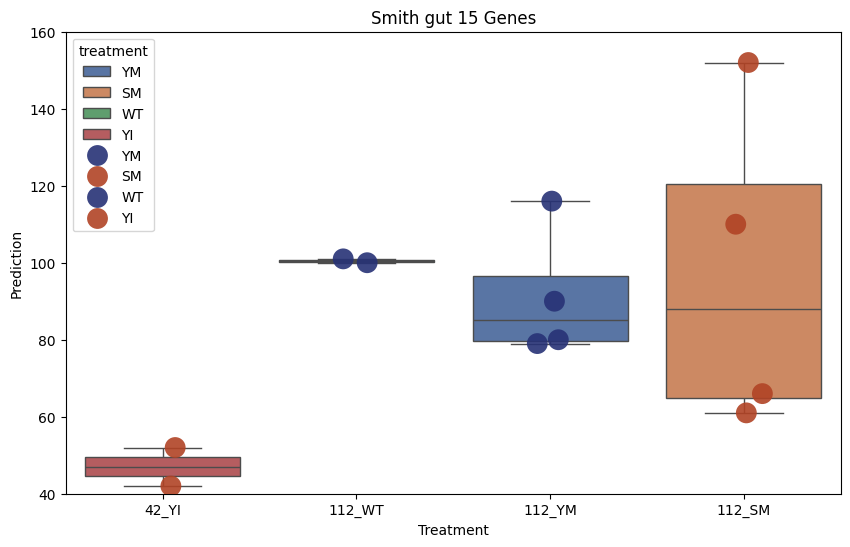

In [ ]:
ordered_x = [
    '42_YI',
    '112_WT', '112_YM','112_SM',
]


# Create the box plot
plt.figure(figsize=(10, 6))
box = sns.boxplot(x='age_treatment', y='prediction', hue='treatment', data=df_intervention_test_pred, palette='deep', showfliers = False,
    order = ordered_x)

# Add data points

custom_palette = ['#273276', '#B14325']  # Use desired hex color codes

# Add data points with custom colors
strip = sns.stripplot(
    x='age_treatment',
    y='prediction',
    hue='treatment',
    data=df_intervention_test_pred,
    palette=custom_palette,  # Custom color palette
    dodge=False,
    alpha=0.9,
    jitter=True,
    size=15,
    order = ordered_x
)

# Remove the legend if not needed
#strip.legend_.remove()

# Customize the plot
plt.title("".join(['Smith gut ', str(gene_number), ' Genes']))
plt.xlabel('Treatment')
plt.ylabel('Prediction')

# Set y-axis limits
plt.ylim(40, 160)

# Remove the grid
plt.grid(False)

# Show the plot
plt.show()

In [ ]:
df_intervention_test_pred.to_csv("./df_prediction_BayesAge_sex_specific_smith_male.csv", sep="\t")

### Try several gene set sizes

In [ ]:
# Set up ordered x-axis for plots
ordered_x = [
    '42_YI',
    '112_WT', '112_YM','112_SM',
]

# Custom color palette
custom_palette = ['#273276', '#B14325']

# Directory setup
os.makedirs("./predictions", exist_ok=True)
os.makedirs("./plots", exist_ok=True)

# Dictionary to store prediction DataFrames if needed later
all_predictions = {}

# Loop through gene numbers
for gene_number in range(5, 51, 5):
    print(f"Running prediction for top {gene_number} genes...")

    df_intervention_test_pred = pd.DataFrame(index=df_intervention_test.index, columns=["prediction"])

    for sample in df_intervention_test.index.tolist():
        reference_df = pd.read_csv(f"./gut/reference/killifish_gut_reference_male", sep="\t", index_col=0)
        top_genes = reference_df["spearman_rank"].abs().nlargest(gene_number).index.tolist()

        total_reads_sample = df_intervention_test_counts.loc[sample].sum()
        list_of_profile_probabilities_per_age = []

        for age in new_age_steps:
            log_probs = []
            for gene in top_genes:
                gene_frequency = reference_df.loc[gene, str(age)]
                gene_frequency = max(gene_frequency, 1e-10)  # Ensure >0

                expected = gene_frequency * total_reads_sample
                observed = df_intervention_test_counts.loc[sample, gene]

                poisson_prob = poisson.pmf(k=observed, mu=expected)
                poisson_prob = max(poisson_prob, 0.001)

                log_probs.append(np.log(poisson_prob))

            list_of_profile_probabilities_per_age.append(np.sum(log_probs))

        age_probability_df = pd.DataFrame({"Pr": list_of_profile_probabilities_per_age}, index=new_age_steps)
        max_probability_age = round(float(age_probability_df.idxmax().iloc[0]), 2)
        df_intervention_test_pred.loc[sample, "prediction"] = max_probability_age

    # Add metadata
    df_intervention_test_pred["treatment"] = df_intervention_test["treatment"].tolist()
    df_intervention_test_pred["age"] = df_intervention_test["age"].tolist()
    df_intervention_test_pred["age_treatment"] = (
        df_intervention_test_pred["age"].astype(str) + "_" +
        df_intervention_test_pred["treatment"].astype(str)
    )

    # Save predictions
    all_predictions[gene_number] = df_intervention_test_pred.copy()
    df_intervention_test_pred.to_csv(f"./predictions/age_preds_top_{gene_number}_genes.tsv", sep="\t")

    print(f"Saved plot and prediction for {gene_number} genes.\n")


Running prediction for top 5 genes...
Saved plot and prediction for 5 genes.

Running prediction for top 10 genes...
Saved plot and prediction for 10 genes.

Running prediction for top 15 genes...
Saved plot and prediction for 15 genes.

Running prediction for top 20 genes...
Saved plot and prediction for 20 genes.

Running prediction for top 25 genes...
Saved plot and prediction for 25 genes.

Running prediction for top 30 genes...
Saved plot and prediction for 30 genes.

Running prediction for top 35 genes...
Saved plot and prediction for 35 genes.

Running prediction for top 40 genes...
Saved plot and prediction for 40 genes.

Running prediction for top 45 genes...
Saved plot and prediction for 45 genes.

Running prediction for top 50 genes...
Saved plot and prediction for 50 genes.



### plot stability of preds

/tmp/ipython-input-2841187593.py:44: UserWarning: 
The palette list has fewer values (2) than needed (4) and will cycle, which may produce an uninterpretable plot.
  sns.stripplot(
/tmp/ipython-input-2841187593.py:44: UserWarning: 
The palette list has fewer values (2) than needed (4) and will cycle, which may produce an uninterpretable plot.
  sns.stripplot(
/tmp/ipython-input-2841187593.py:44: UserWarning: 
The palette list has fewer values (2) than needed (4) and will cycle, which may produce an uninterpretable plot.
  sns.stripplot(
/tmp/ipython-input-2841187593.py:44: UserWarning: 
The palette list has fewer values (2) than needed (4) and will cycle, which may produce an uninterpretable plot.
  sns.stripplot(
/tmp/ipython-input-2841187593.py:44: UserWarning: 
The palette list has fewer values (2) than needed (4) and will cycle, which may produce an uninterpretable plot.
  sns.stripplot(
/tmp/ipython-input-2841187593.py:44: UserWarning: 
The palette list has fewer values (2) than n

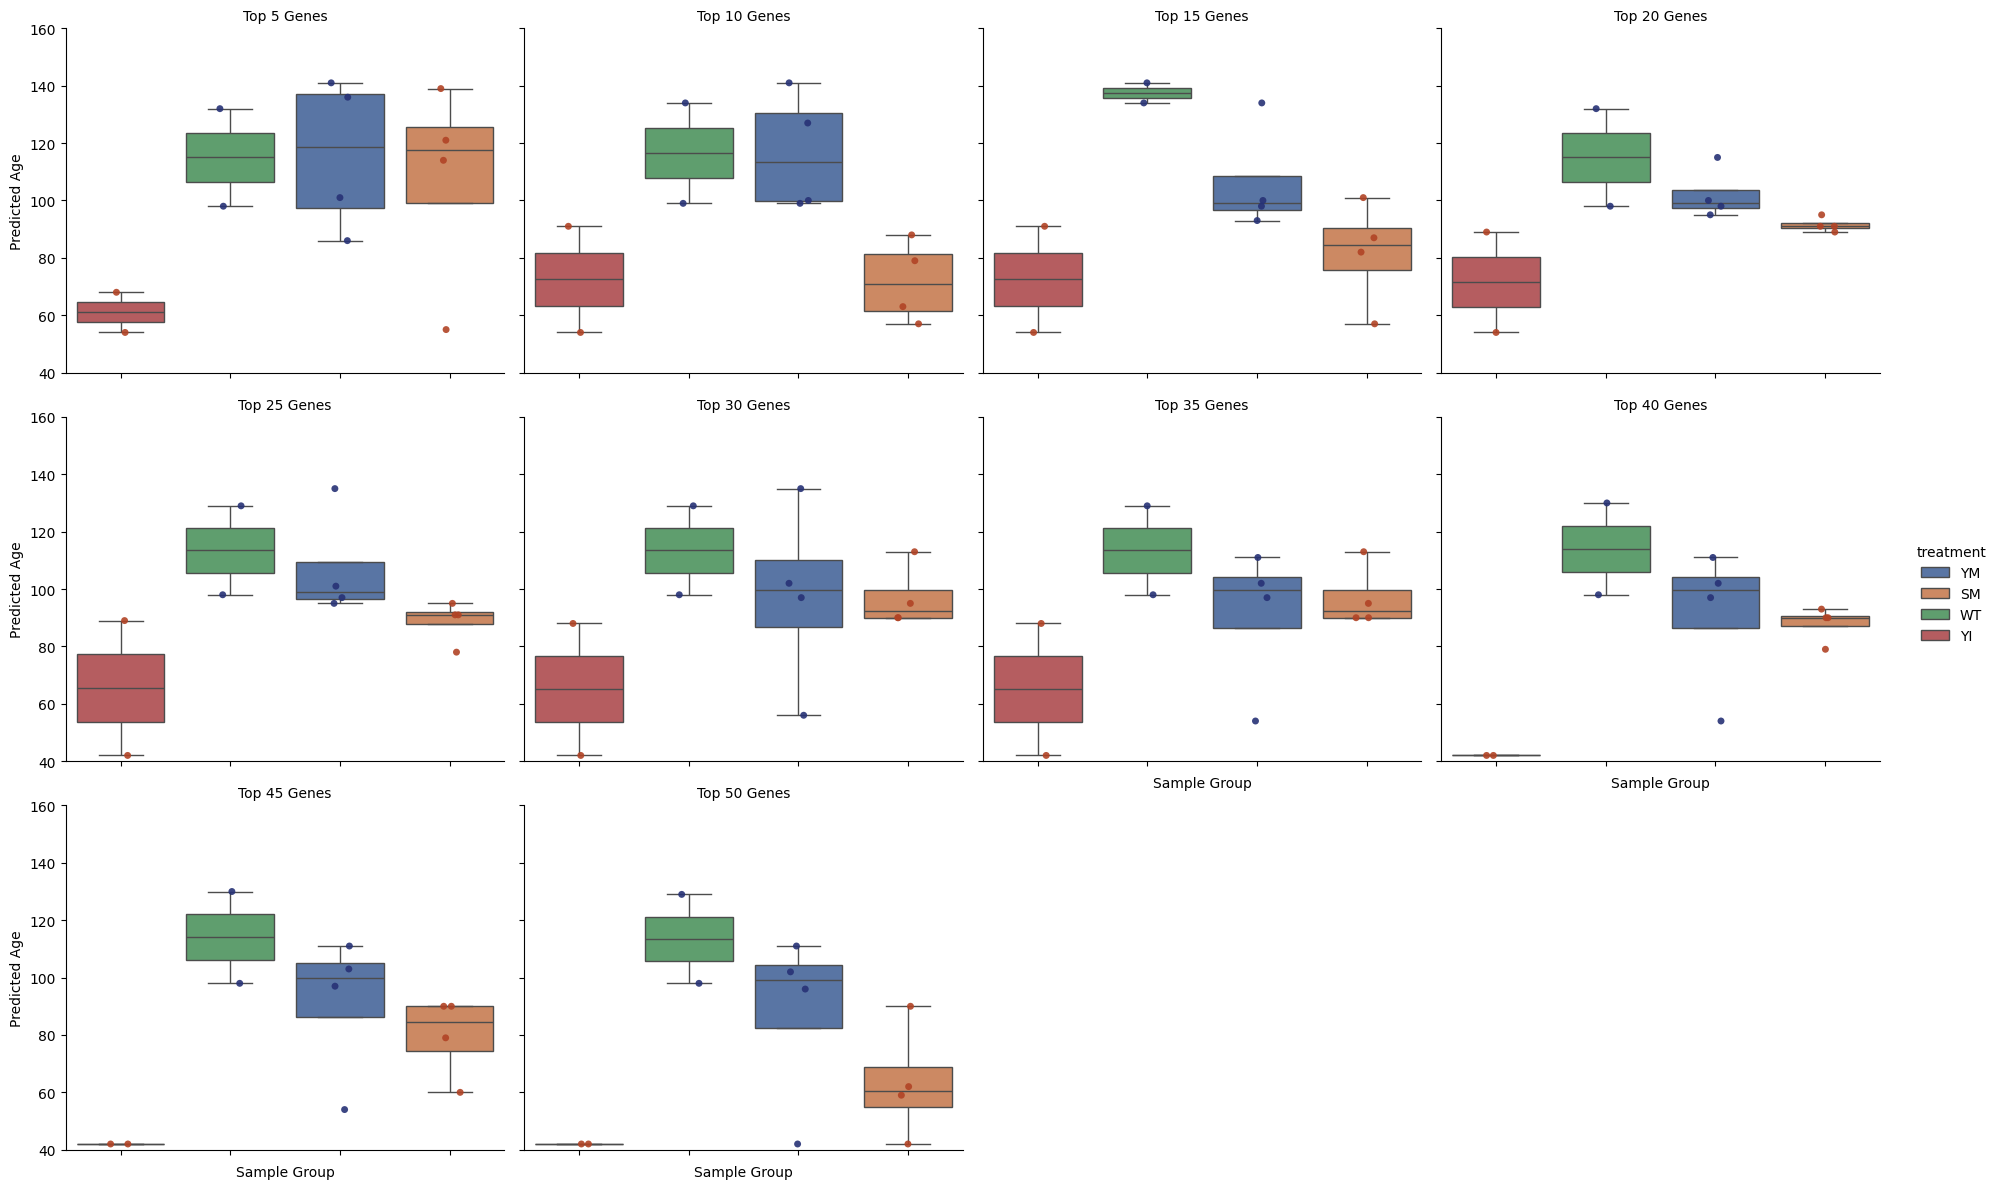

In [ ]:
# Ordered x-axis
ordered_x = [
    '42_YI',
    '112_WT', '112_YM','112_SM',
]

# Custom palette
custom_palette = ['#273276', '#B14325']

# Load all prediction files
all_predictions_list = []

for gene_number in range(5, 51, 5):
    file_path = f"./predictions/age_preds_top_{gene_number}_genes.tsv"
    if os.path.exists(file_path):
        df = pd.read_csv(file_path, sep="\t", index_col=0)
        df["gene_number"] = str(gene_number)  # for cleaner facet titles
        all_predictions_list.append(df)
    else:
        print(f"Warning: {file_path} not found. Skipping.")

# Concatenate into a single DataFrame
all_predictions_df = pd.concat(all_predictions_list, axis=0)

# Plot with seaborn FacetGrid (catplot)
g = sns.catplot(
    data=all_predictions_df,
    x="age_treatment",
    y="prediction",
    hue="treatment",
    col="gene_number",
    col_wrap=4,
    kind="box",
    palette='deep',
    order=ordered_x,
    height=4,
    aspect=1.2,
    showfliers=False
)

# Overlay stripplot for better visualization
for ax, gene_number in zip(g.axes.flat, all_predictions_df["gene_number"].unique()):
    subset = all_predictions_df[all_predictions_df["gene_number"] == gene_number]
    sns.stripplot(
        x='age_treatment',
        y='prediction',
        hue='treatment',
        data=subset,
        palette=custom_palette,
        dodge=False,
        alpha=0.9,
        jitter=True,
        size=5,
        order=ordered_x,
        ax=ax,
        legend=False
    )
    ax.set_title(f"Top {gene_number} Genes")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_ylim(40, 160)

g.set_axis_labels("Sample Group", "Predicted Age")
g.set_titles("Top {col_name} Genes")
g.tight_layout()
plt.savefig("./plots/faceted_predictions_by_gene_number.svg", dpi=300, bbox_inches="tight")
plt.show()


# Male - gut rotate training samples

In [ ]:
#------------------------------------------------------------
# Sample selection setup
#------------------------------------------------------------
#select two AL samples for calibration
all_samples = df_intervention_male.index
WT_samples = df_intervention[df_intervention['training'] == 'Yes'].index

# Separate the samples
young_samples = [s for s in WT_samples if '.6wk' in s.lower()]
old_samples = [s for s in WT_samples if '.16wk' in s.lower()]

# Create all 2x2 combinations
young_combos = list(itertools.combinations(young_samples, 2))
old_combos = list(itertools.combinations(old_samples, 2))


#------------------------------------------------------------
# Loop through all young-old combinations
#------------------------------------------------------------
for y_combo in young_combos:
    for o_combo in old_combos:

        combo_id = f"{'_'.join(map(str, y_combo))}__{'_'.join(map(str, o_combo))}"
        print(f"\nRunning combo: {combo_id}")

        # Select samples for training
        select_train_samples = list(y_combo) + list(o_combo)
        df_intervention_train = df_intervention_male.loc[select_train_samples]
        df_intervention_train = df_intervention_train[tissue_df_counts.columns]  # match columns

        # Combine with atlas
        atlas_plus_intervention = pd.concat([tissue_df_counts, df_intervention_train], axis=0)
        age_steps = sorted(atlas_plus_intervention["age"].value_counts().index.tolist())
        atlas_plus_intervention = atlas_plus_intervention.drop(atlas_plus_intervention.columns[[-1, -3, -4]], axis=1)

        # Get test set
        test_samples = [s for s in df_intervention_male.index if s not in select_train_samples]
        df_intervention_test = df_intervention_male.loc[test_samples]
        df_intervention_test_counts = df_intervention_test.drop(
            df_intervention_test.columns[[-2, -3, -4, -5,-6]], axis=1
        )

        #check cols ordered the same
        df_intervention_test_counts = df_intervention_test_counts[atlas_plus_intervention.columns]
        df_intervention_test_counts.head(2)

        # Save per-sample reference files
        for sample in atlas_plus_intervention.index:
            atlas_plus_intervention.drop(sample).to_csv(
                f"./reference/gut_sample_{sample}_{combo_id}.csv", sep="\t"
            )

        new_age_steps = np.arange(min(age_steps), max(age_steps) + 1, 1)


        # Run transcriptome_reference (assuming it handles saving internally)
        transcriptome_reference(
            training_matrix=atlas_plus_intervention,
            reference_name=f"killifish_gut_ref_male_{combo_id}",
            output_path="./reference_exhaustive/",
            age_prediction="list",
            age_list=new_age_steps,
            min_age=1,
            max_age=24,
            age_step=1,
            tau=0.7
        )


        # Run predictions for a single gene number or loop over multiple
        for gene_number in range(5, 51, 5):
            df_pred = pd.DataFrame(index=df_intervention_test.index, columns=["prediction"])
            reference_df = pd.read_csv(
                f"./reference_exhaustive/killifish_gut_ref_male_{combo_id}", sep="\t", index_col=0
            )
            top_genes = reference_df["spearman_rank"].abs().nlargest(gene_number).index.tolist()

            for sample in df_intervention_test.index:
                total_reads = df_intervention_test_counts.loc[sample].sum()
                log_sums = []
                for age in new_age_steps:
                    logP = []
                    for gene in top_genes:
                        freq = max(reference_df.loc[gene, str(age)], 1e-10)
                        mu = freq * total_reads
                        obs = df_intervention_test_counts.loc[sample, gene]
                        p = max(poisson.pmf(obs, mu), 0.001)
                        logP.append(np.log(p))
                    log_sums.append(np.sum(logP))

                pred_age = round(float(new_age_steps[np.argmax(log_sums)]), 2)
                df_pred.loc[sample, "prediction"] = pred_age

            # Add metadata and save
            df_pred["treatment"] = df_intervention_test["treatment"]

            # Save prediction results
            df_pred.to_csv(
                f"./predictions_exhaustive/male_pred_top_{gene_number}_{combo_id}.tsv", sep="\t"
            )



Running combo: A3.YI.6wk.3_A2.YI.6wk.1__B7.WT.16wk.6_B5.WT.16wk.1


/tmp/ipython-input-2002720175.py:41: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(age_training, gene_frequency)



Reference model dataset written to './reference_exhaustive/killifish_gut_ref_male_A3.YI.6wk.3_A2.YI.6wk.1__B7.WT.16wk.6_B5.WT.16wk.1'
Report file generated at './reference_exhaustive/killifish_gut_ref_male_A3.YI.6wk.3_A2.YI.6wk.1__B7.WT.16wk.6_B5.WT.16wk.1.report.txt'
-----------------------------------------------------



Time to run construct reference: 103.314 seconds

The reference is constructed and saved!

Running combo: A3.YI.6wk.3_A2.YI.6wk.1__B7.WT.16wk.6_B8.WT.16wk.7


/tmp/ipython-input-2002720175.py:41: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(age_training, gene_frequency)



Reference model dataset written to './reference_exhaustive/killifish_gut_ref_male_A3.YI.6wk.3_A2.YI.6wk.1__B7.WT.16wk.6_B8.WT.16wk.7'
Report file generated at './reference_exhaustive/killifish_gut_ref_male_A3.YI.6wk.3_A2.YI.6wk.1__B7.WT.16wk.6_B8.WT.16wk.7.report.txt'
-----------------------------------------------------



Time to run construct reference: 98.238 seconds

The reference is constructed and saved!

Running combo: A3.YI.6wk.3_A2.YI.6wk.1__B7.WT.16wk.6_B6.WT.16wk.2


...


Reference model dataset written to './reference_exhaustive/killifish_gut_ref_male_A18.YI.6wk.4_A17.YI.6wk.2__B5.WT.16wk.1_B8.WT.16wk.7'
Report file generated at './reference_exhaustive/killifish_gut_ref_male_A18.YI.6wk.4_A17.YI.6wk.2__B5.WT.16wk.1_B8.WT.16wk.7.report.txt'
-----------------------------------------------------



Time to run construct reference: 97.422 seconds

The reference is constructed and saved!

Running combo: A18.YI.6wk.4_A17.YI.6wk.2__B5.WT.16wk.1_B6.WT.16wk.2


/tmp/ipython-input-2002720175.py:41: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(age_training, gene_frequency)



Reference model dataset written to './reference_exhaustive/killifish_gut_ref_male_A18.YI.6wk.4_A17.YI.6wk.2__B5.WT.16wk.1_B6.WT.16wk.2'
Report file generated at './reference_exhaustive/killifish_gut_ref_male_A18.YI.6wk.4_A17.YI.6wk.2__B5.WT.16wk.1_B6.WT.16wk.2.report.txt'
-----------------------------------------------------



Time to run construct reference: 97.199 seconds

The reference is constructed and saved!

Running combo: A18.YI.6wk.4_A17.YI.6wk.2__B8.WT.16wk.7_B6.WT.16wk.2


/tmp/ipython-input-2002720175.py:41: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(age_training, gene_frequency)



Reference model dataset written to './reference_exhaustive/killifish_gut_ref_male_A18.YI.6wk.4_A17.YI.6wk.2__B8.WT.16wk.7_B6.WT.16wk.2'
Report file generated at './reference_exhaustive/killifish_gut_ref_male_A18.YI.6wk.4_A17.YI.6wk.2__B8.WT.16wk.7_B6.WT.16wk.2.report.txt'
-----------------------------------------------------



Time to run construct reference: 97.172 seconds

The reference is constructed and saved!
